In [2]:
!pip install pandas requests sqlalchemy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

df = pd.read_csv("games_details.csv")

df.head()

C:\Users\X1 YOGA\AppData\Local\Temp\ipykernel_1956\1482402921.py:3: DtypeWarning: Columns (0: NICKNAME) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("games_details.csv")


,GAME_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,PLAYER_NAME,NICKNAME,START_POSITION,COMMENT,MIN,...,OREB,DREB,REB,AST,STL,BLK,TO,PF,PTS,PLUS_MINUS
0,22200477,1610612759,SAS,San Antonio,1629641,Romeo Langford,Romeo,F,NaN,18:06,...,1.0,1.0,2.0,0.0,1.0,0.0,2.0,5.0,2.0,-2.0
1,22200477,1610612759,SAS,San Antonio,1631110,Jeremy Sochan,Jeremy,F,NaN,31:01,...,6.0,3.0,9.0,6.0,1.0,0.0,2.0,1.0,23.0,-14.0
2,22200477,1610612759,SAS,San Antonio,1627751,Jakob Poeltl,Jakob,C,NaN,21:42,...,1.0,3.0,4.0,1.0,1.0,0.0,2.0,4.0,13.0,-4.0
3,22200477,1610612759,SAS,San Antonio,1630170,Devin Vassell,Devin,G,NaN,30:20,...,0.0,9.0,9.0,5.0,3.0,0.0,2.0,1.0,10.0,-18.0
4,22200477,1610612759,SAS,San Antonio,1630200,Tre Jones,Tre,G,NaN,27:44,...,0.0,2.0,2.0,3.0,0.0,0.0,2.0,2.0,19.0,0.0


In [4]:
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 668628 entries, 0 to 668627
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   GAME_ID            668628 non-null  int64  
 1   TEAM_ID            668628 non-null  int64  
 2   TEAM_ABBREVIATION  668628 non-null  str    
 3   TEAM_CITY          668628 non-null  str    
 4   PLAYER_ID          668628 non-null  int64  
 5   PLAYER_NAME        668628 non-null  str    
 6   NICKNAME           53037 non-null   str    
 7   START_POSITION     255765 non-null  str    
 8   COMMENT            109689 non-null  str    
 9   MIN                558938 non-null  str    
 10  FGM                558938 non-null  float64
 11  FGA                558938 non-null  float64
 12  FG_PCT             558938 non-null  float64
 13  FG3M               558938 non-null  float64
 14  FG3A               558938 non-null  float64
 15  FG3_PCT            558938 non-null  float64
 16  FTM          

In [ ]:
## Drop irrelevant columns that do not contribute to analysis
# 'NICKNAME' and 'COMMENT' contain excessive missing values and are not useful for performance analysis

In [5]:
df = df.drop(columns=['NICKNAME', 'COMMENT'])

In [ ]:
# Remove rows where players did not participate in the game
# Missing 'MIN' indicates the player did not play (DNP - Did Not Play)

In [6]:
df = df.dropna(subset=['MIN'])

In [ ]:
# Convert 'MIN' column from string format (e.g., "12:34") to numeric minutes
# Extract only the minutes component and convert to numeric type

In [7]:
df['MIN'] = df['MIN'].str.split(':').str[0]
df['MIN'] = pd.to_numeric(df['MIN'], errors='coerce')

In [ ]:
# List of statistical columns to ensure proper numeric formatting
# Convert all statistical columns to numeric type for accurate analysis
# Errors are coerced to NaN to handle unexpected string values

In [8]:
stat_cols = [
    'FGM','FGA','FG_PCT','FG3M','FG3A','FG3_PCT',
    'FTM','FTA','FT_PCT','OREB','DREB','REB',
    'AST','STL','BLK','TO','PF','PTS','PLUS_MINUS'
]

for col in stat_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
# Remove rows with missing key performance metrics
# PTS (points), AST (assists), and REB (rebounds) are essential for player performance analysis

In [9]:
df = df.dropna(subset=['PTS', 'AST', 'REB'])

In [ ]:
# Remove duplicate records to maintain data integrity

In [10]:
df = df.drop_duplicates()

In [ ]:
# Filter out invalid or unrealistic values (e.g., negative points)
# Ensures consistency and reliability of the dataset

In [11]:
df = df[df['PTS'] >= 0]

In [12]:
df.shape

(558938, 27)

In [13]:
# Identify top players based on average points per game
top_scorers = df.groupby('PLAYER_NAME')['PTS'].mean().sort_values(ascending=False).head(10)

top_scorers

PLAYER_NAME
Kevin Durant       27.074539
Luka Doncic        26.941003
LeBron James       26.834292
Kobe Bryant        26.621463
Allen Iverson      25.863341
Joel Embiid        25.607229
Zion Williamson    25.049587
Trae Young         25.039548
Damian Lillard     24.353081
Stephen Curry      24.318267
Name: PTS, dtype: float64

In [14]:
# Identify players with highest average assists
top_assists = df.groupby('PLAYER_NAME')['AST'].mean().sort_values(ascending=False).head(10)

top_assists

PLAYER_NAME
Steve Nash           10.073529
Chris Paul            9.268710
Trae Young            8.940678
John Wall             8.787795
Russell Westbrook     8.233607
Jason Kidd            7.905639
Luka Doncic           7.879056
Rajon Rondo           7.850515
Deron Williams        7.807654
Ben Simmons           7.515670
Name: AST, dtype: float64

In [15]:
# Identify players with highest average rebounds
top_rebounds = df.groupby('PLAYER_NAME')['REB'].mean().sort_values(ascending=False).head(10)

top_rebounds

PLAYER_NAME
Andre Drummond        12.815854
Dwight Howard         11.634416
Rudy Gobert           11.462277
Joel Embiid           11.009639
Karl-Anthony Towns    10.983607
Marcus Camby          10.718935
Hassan Whiteside      10.500000
Clint Capela          10.347541
Deandre Ayton         10.341693
Kevin Love            10.300626
Name: REB, dtype: float64

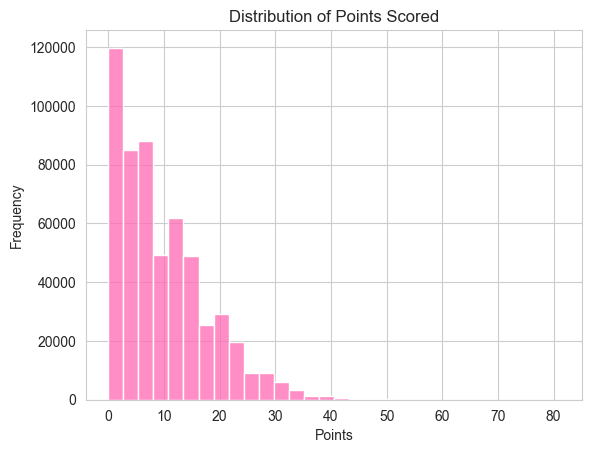

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.histplot(df['PTS'], bins=30, color='#ff69b4')  # hot pink

plt.title("Distribution of Points Scored")
plt.xlabel("Points")
plt.ylabel("Frequency")

plt.show()

In [19]:
# Analyze correlation between key performance metrics
df[['PTS','AST','REB']].corr()

,PTS,AST,REB
PTS,1.000000,0.431907,0.439461
AST,0.431907,1.000000,0.169356
REB,0.439461,0.169356,1.000000


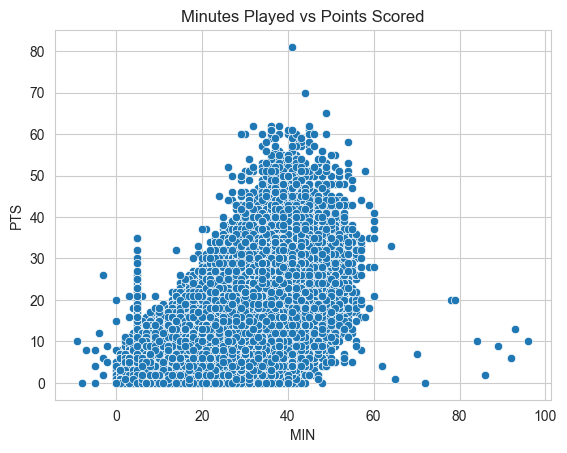

In [20]:
# Check if playing more minutes leads to higher scoring
sns.scatterplot(x=df['MIN'], y=df['PTS'])
plt.title("Minutes Played vs Points Scored")
plt.show()

In [ ]:
#Curry's stats

In [22]:
curry_df = df[df['PLAYER_NAME'] == 'Stephen Curry']
curry_df[['PTS', 'AST', 'REB']].head()
curry_df[['PTS', 'AST', 'REB']].mean()


PTS    24.318267
AST     6.366290
REB     4.705273
dtype: float64

In [25]:
curry_df = curry_df.reset_index(drop=True)

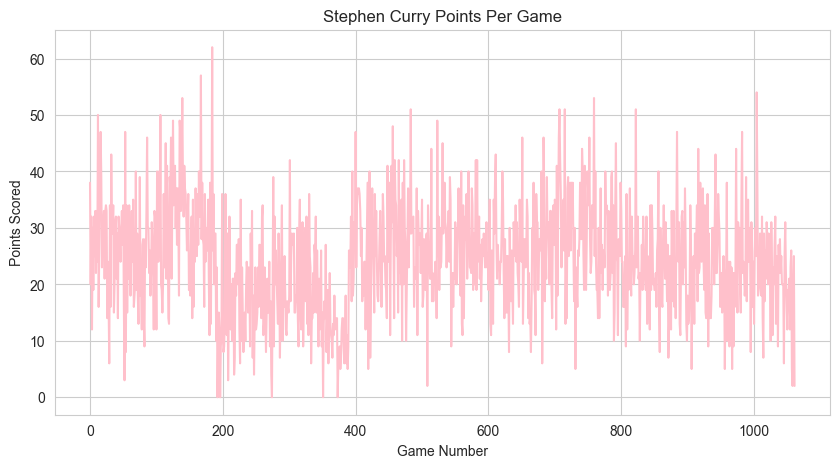

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(curry_df['PTS'], color='pink')

plt.title("Stephen Curry Points Per Game")
plt.xlabel("Game Number")
plt.ylabel("Points Scored")

plt.show()

In [27]:
# Features (inputs)
X = df[['AST', 'REB', 'MIN']]

# Target (output we want to predict)
y = df['PTS']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mse

29.75308597320171

In [33]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mse

29.75308597320171

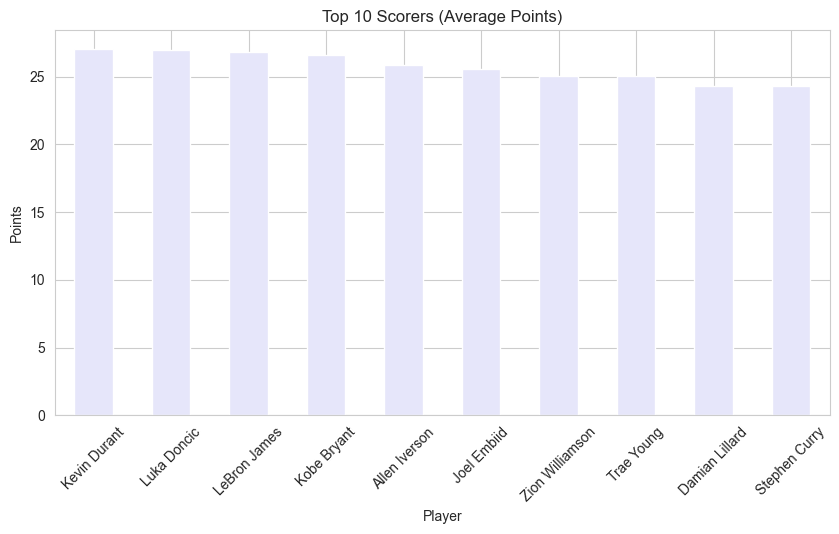

In [39]:
import matplotlib.pyplot as plt

top_scorers = df.groupby('PLAYER_NAME')['PTS'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_scorers.plot(kind='bar', color='lavender')

plt.title("Top 10 Scorers (Average Points)")
plt.xlabel("Player")
plt.ylabel("Points")

plt.xticks(rotation=45)
plt.show()

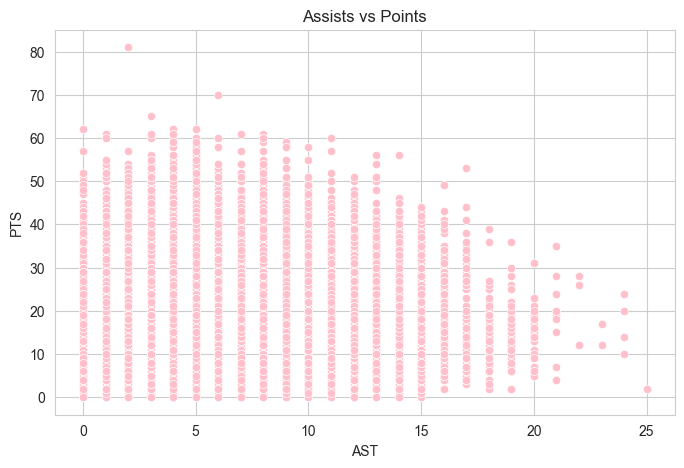

In [40]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['AST'], y=df['PTS'], color='pink')

plt.title("Assists vs Points")
plt.show()

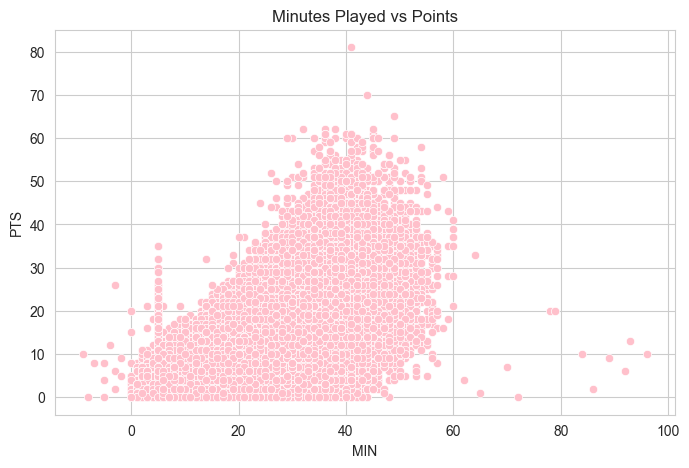

In [44]:
plt.figure(figsize=(8,5)) 
sns.scatterplot(x=df['MIN'], y=df['PTS'], color='pink')

plt.title("Minutes Played vs Points") 
plt.show()

In [ ]:
## Insight:
There is a positive relationship between minutes played and points scored, indicating that players with higher playtime tend to score more.

In [45]:
##Dashboard

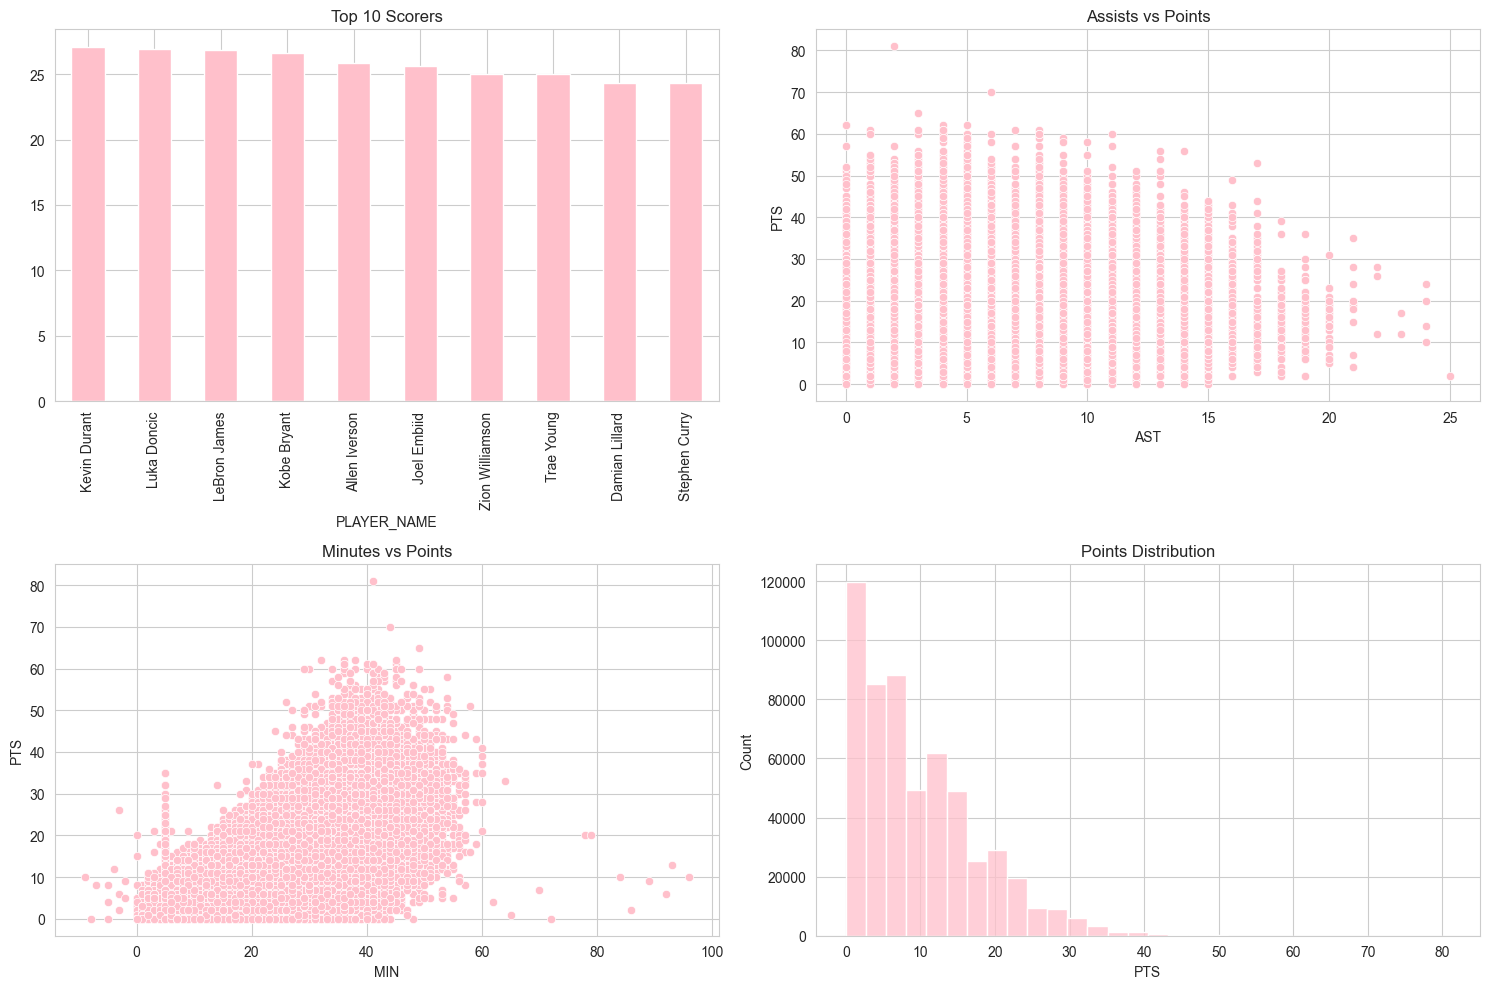

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

# 1. Top Scorers
plt.subplot(2,2,1)
top_scorers = df.groupby('PLAYER_NAME')['PTS'].mean().sort_values(ascending=False).head(10)
top_scorers.plot(kind='bar', color='pink')
plt.title("Top 10 Scorers")

# 2. Assists vs Points
plt.subplot(2,2,2)
sns.scatterplot(x=df['AST'], y=df['PTS'], color='pink')
plt.title("Assists vs Points")

# 3. Minutes vs Points
plt.subplot(2,2,3)
sns.scatterplot(x=df['MIN'], y=df['PTS'], color='pink')
plt.title("Minutes vs Points")

# 4. Points Distribution
plt.subplot(2,2,4)
sns.histplot(df['PTS'], bins=30, color='pink')
plt.title("Points Distribution")

plt.tight_layout()
plt.show()